<a href="https://colab.research.google.com/github/malak-mahdaoui/Character-Level-Language-Model-using-LSTM/blob/main/Generation_texte_LSTM_PyTorch_enonce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


#  Génération de texte avec LNN (PyTorch)

**Objectif :** entraîner un modèle de langage caractère-par-caractère (Embedding + LSTM) pour générer du texte à partir d’un corpus.
Nous allons :
1. Préparer les données (caractères → entiers, séquences glissantes).
2. Implémenter un modèle LSTM en PyTorch.
3. Entraîner le modèle avec `CrossEntropyLoss`.
4. Générer du texte avec un **contrôle de température**.
5. Sauvegarder/charger le modèle pour réutiliser l'entraînement.

> 💡 Ce TP est autonome : il peut s'exécuter sur CPU. Si vous avez un GPU CUDA disponible, le notebook l'utilisera automatiquement.



## 0. Préliminaires

- Bibliothèques nécessaires : `torch`, `matplotlib`, `numpy` (toutes disponibles sur la plupart des distributions Python scientifiques).
- **Données** : vous pouvez fournir le chemin vers un fichier `.txt` local (français, anglais, etc.).
  - Si aucun fichier n'est donné, on utilisera un court extrait *domaine public* (Voltaire, *Candide*, 1759) pour que tout s'exécute immédiatement.
- Le modèle travaille **au niveau caractère** (simple et robuste). En fin de TP, des pistes d'extensions vous invitent à passer **au niveau mot**.


In [ ]:
import os, json, math, random, time
from dataclasses import dataclass

import torch
import torch.nn as nn


import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, Subset

# Reproductibilité
SEED = 1234
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

def get_device():
    mps_ok = hasattr(torch.backends, "mps") and torch.backends.mps.is_built() and torch.backends.mps.is_available()
    #if mps_ok:
    #    return torch.device("mps"), "mps (Apple Metal)"
    if torch.cuda.is_available():
        name = torch.cuda.get_device_name(0)
        return torch.device("cuda"), f"cuda ({name})"
    return torch.device("cpu"), "cpu"

device, device_name = get_device()
print(f"Device: {device} — {device_name}")

Device: cpu — cpu



## 1. Chargement du corpus texte

- Indiquez `TEXT_PATH` si vous avez un fichier local (ex. `data/mon_corpus.txt`).  
- Sinon laissez `None` pour utiliser un extrait de *Candide* (Voltaire) — **domaine public**.


In [ ]:

# Renseignez le chemin de votre fichier texte ici (ou laissez None)
TEXT_PATH = None  # ex: 'data/les_miserables.txt'

candide_excerpt = """ Dans le château de Thunder-ten-tronckh, en Westphalie, vivait un jeune garçon à qui la nature avait donné les mœurs les plus douces.
Sa physionomie annonçait son âme. Il avait le jugement assez droit, avec l’esprit le plus simple ; c’est, je crois, pour cette raison qu’on le nommait Candide.
Les anciens domestiques de la maison soupçonnaient qu’il était fils de la sœur de monsieur le baron, et d’un bon et honnête gentilhomme du voisinage,
que cette demoiselle ne voulut jamais épouser parce qu’il n’avait pu prouver que soixante et onze quartiers,
et que le reste de son arbre généalogique avait été perdu par l’injure du temps. """

if TEXT_PATH is not None and os.path.isfile(TEXT_PATH):
    with open(TEXT_PATH, 'r', encoding='utf-8') as f:
        text = f.read()
else:
    print("Aucun fichier fourni → utilisation d'un court extrait de *Candide* (Voltaire, 1759).")
    text = candide_excerpt

len(text), text[:300]


Aucun fichier fourni → utilisation d'un court extrait de *Candide* (Voltaire, 1759).


(635,
 ' Dans le château de Thunder-ten-tronckh, en Westphalie, vivait un jeune garçon à qui la nature avait donné les mœurs les plus douces. \nSa physionomie annonçait son âme. Il avait le jugement assez droit, avec l’esprit le plus simple\xa0; c’est, je crois, pour cette raison qu’on le nommait Candide.\nLes a')


## 2. Pré-traitement : vocabulaire & encodage caractère

- Construction du vocabulaire à partir des caractères observés.
- Encodage en indices entiers (0..|V|-1).
- **Séquences glissantes** de longueur `seq_len` : on prédit le **caractère suivant** à chaque pas de temps.



### Exercice 1 — Vocabulaire & encodage (à compléter)

**But :** Construire un vocabulaire caractère ↔ id et écrire les fonctions `encode` et `decode`.
1. Créez `chars`, `stoi` (char→id) et `itos` (id→char).
2. Implémentez `encode(s)` et `decode(ids)`.
3. Vérifiez en encodant/décodant un petit extrait : `decode(encode("Bonjour"))`.

> Indices : `sorted(set(text))` donne l’ensemble des caractères ; un dict-comprehension permet de numéroter.


In [ ]:
import torch

# ================================
# EXERCICE 1 : Vocabulaire & encodage
# ================================

# Exemple : votre texte (remplacez par votre corpus réel)
# text = "Votre texte ici..."
# Assurez-vous que la variable text existe avant d'exécuter le bloc.

STUDENT_MODE = False  # mettre True si vous voulez le faire vous-même

# 1) Construction du vocabulaire
chars = sorted(list(set(text)))
stoi  = {ch: i for i, ch in enumerate(chars)}
itos  = {i: ch for ch, i in stoi.items()}

vocab_size = len(stoi)
print(f" Taille du vocabulaire : {vocab_size} caractères")

# 2) Fonctions encode / decode
if STUDENT_MODE:
    def encode(s: str):
        """Retourne une liste d'ids pour la chaîne s, en utilisant stoi."""
        return [stoi[c] for c in s]

    def decode(ids):
        """Retourne une chaîne depuis une liste d'ids, en utilisant itos."""
        return ''.join(itos[i] for i in ids)

else:
    # Version solution (robuste)
    def encode(s: str):
        return [stoi[c] for c in s if c in stoi]

    def decode(ids):
        return ''.join(itos[i] for i in ids)

# 3) Encodage du corpus complet
encoded = torch.tensor(encode(text), dtype=torch.long)
print(" Longueur du texte encodé :", len(encoded))

# 4) Test rapide
test = "Bonjour"
print(" Test decode(encode(\"bonjour\")) →", decode(encode(test)))


 Taille du vocabulaire : 46 caractères
 Longueur du texte encodé : 635
 Test decode(encode("bonjour")) → onjour


on va extraire tous les caracters uniques et puis on va les trier dans l'ordre alphabetique donc on obtient une liste de tous les caractères possibles dans le dataset. Apres on va decouvrir chaque caractere to id (entier) donc chaque caractere recoit un numero unique ce qui est indispensable pour l'entrainement de modele
Et puis a partir du sequence d'id on va reconstruire le texte .

###Fonction Encode/Decode :
**encode**
Convertit une phrase en une liste d'IDs (nombres).pour que le modele de deep learning comprend les entrees .

**decode(ids)**
Convertit une liste d'IDs en texte lisible.


## 3. Jeu de données & DataLoader

On forme des couples (**entrée**; **cible**) où :
- entrée: une séquence de longueur `seq_len`,
- cible: la **même séquence décalée d'une position**, donc longueur `seq_len`.



### Exercice 2 — Dataset caractère & DataLoader (à compléter)

**But :** Créer un `Dataset` qui renvoie, pour un index `i`, une paire `(x, y)` où :
- `x` = `data[i : i+seq_len]`
- `y` = `data[i+1 : i+1+seq_len]` (séquence *décalée* d'un cran)

Ensuite, constituez les `DataLoader` d'entraînement/validation (split **90/10**).


In [ ]:
from dataclasses import dataclass
from torch.utils.data import Dataset, DataLoader, Subset
import torch

# ==========================================
# CONFIG
# ==========================================
@dataclass
class LMConfig:
    seq_len: int = 120      # Longueur d'une séquence d'entrée
    batch_size: int = 64    # Nombre d'exemples par batch
    num_workers: int = 0    # 0 = compatible notebooks/windows
    drop_last: bool = True  # On ignore le dernier batch incomplet

cfg = LMConfig()

# ==========================================
# DATASET CARACTÈRES
# ==========================================
class CharDataset(Dataset):
    def __init__(self, encoded_tensor: torch.Tensor, seq_len: int):
        self.data = encoded_tensor        # texte encodé → tensor d’IDs
        self.seq_len = seq_len            # longueur d'entrée (fenêtre)

    def __len__(self):
        # Nombre d'exemples possibles
        return max(0, len(self.data) - self.seq_len - 1)

    def __getitem__(self, idx):
        # x = séquence de longueur seq_len
        x = self.data[idx : idx + self.seq_len]

        # y = la même séquence décalée d’un cran (target)
        y = self.data[idx + 1 : idx + 1 + self.seq_len]

        return x, y

# ==========================================
# INSTANTIATION DU DATASET COMPLET
# ==========================================
dataset = CharDataset(encoded, cfg.seq_len)

# ==========================================
# SPLIT TRAIN / VALIDATION  (90 / 10)
# ==========================================
n = len(dataset)
n_train = int(0.9 * n)
n_val = n - n_train

# Indices mélangés
indices = torch.randperm(n).tolist()
train_idx = indices[:n_train]
val_idx   = indices[n_train:]

# Sous-datasets
train_ds = Subset(dataset, train_idx)
val_ds   = Subset(dataset, val_idx)

# ==========================================
# DATALOADERS
# ==========================================
train_dl = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    drop_last=cfg.drop_last
)

val_dl = DataLoader(
    val_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    drop_last=cfg.drop_last
)

print("Taille train:", len(train_ds))
print("Taille val:", len(val_ds))


Taille train: 462
Taille val: 52



### Expliquation :
1) CharDataset : transforme ton texte en échantillons (x, y)

Il reçoit :
encoded : ton texte encodé en IDs
seq_len = longueur des séquences d'entraînement

2) getitem()
Retourne la paire (x, y) à l’indice idx.

3) Split 90% / 10%
4) DataLoader: Regroupe les données en batches pour entraîner le modèle :

###Donc:
Ce code crée un dataset de séquences (x, y) où y est la même séquence que x mais décalée d’un caractère pour apprendre à prédire le suivant.
Puis il construit les DataLoaders train/validation pour fournir des batches prêts à entraîner un modèle de langage .


## 4. Modèle LSTM (Embedding → LSTM → Linéaire)

- `nn.Embedding(vocab_size, emb_dim)` pour convertir indices en vecteurs denses.
- `nn.LSTM` (unidirectionnel) pour modéliser les dépendances séquentielles.
- `nn.Linear(hidden_dim, vocab_size)` pour prédire la distribution sur les caractères.


In [ ]:

class CharLSTM(nn.Module):
    def __init__(self, vocab_size: int, emb_dim: int = 128, hidden_dim: int = 256, num_layers: int = 2, dropout: float = 0.2):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, emb_dim)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, num_layers=num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        # x: (B, T)
        x = self.embed(x)           # (B, T, E)
        out, hidden = self.lstm(x, hidden)  # out: (B, T, H)
        logits = self.fc(out)       # (B, T, V)
        return logits, hidden

model = CharLSTM(vocab_size=vocab_size).to(device)
print(model)


CharLSTM(
  (embed): Embedding(46, 128)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=256, out_features=46, bias=True)
)



## 5. Entraînement

- **Perte** : `CrossEntropyLoss` appliquée *pas de temps par pas de temps*.
- **Optimiseur** : `Adam` (très correct par défaut).
- **Clipping** des gradients pour éviter l'explosion (optionnel mais prudent).

> Par défaut, nous entraînons peu d'époques pour que ça tourne vite sur CPU. Augmentez `EPOCHS` pour de meilleurs résultats.



### Exercice 3 — Boucle d'entraînement (à compléter)

**But :** Compléter la fonction `iterate_epoch` :
1. Faire la passe avant → `logits, _ = model(xb)`.
2. Calculer la **perte** `CrossEntropy` sur toutes les positions (aplatir `(B,T,V)` et `(B,T)`).
3. En mode `train=True` : *zero_grad → backward → (clip optionnel) → step*.
4. Accumuler la perte moyenne.


In [ ]:
EPOCHS = 3
LR = 3e-3
GRAD_CLIP = 1.0

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

def iterate_epoch(dataloader, train=True):
    model.train(train)     # mode entraînement ou validation
    total_loss, steps = 0.0, 0

    for xb, yb in dataloader:
        xb = xb.to(device)     # (B, T)
        yb = yb.to(device)     # (B, T)

        # ----- PASSE AVANT -----
        logits, _ = model(xb)  # logits shape : (B, T, vocab_size)

        # ----- CALCUL DE LA PERTE -----
        loss = criterion(
            logits.reshape(-1, logits.size(-1)),   # (B*T, V)
            yb.reshape(-1)                         # (B*T)
        )

        # ----- PASSE ARRIÈRE (TRAIN SEULEMENT) -----
        if train:
            optimizer.zero_grad(set_to_none=True)
            loss.backward()

            # Clip des gradients (stabilise l'entraînement)
            if GRAD_CLIP is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

            optimizer.step()

        total_loss += loss.item()
        steps += 1

    return total_loss / max(steps, 1)


# ============================
#   BOUCLE ENTIÈRE
# ============================
train_losses, val_losses = [], []

start = time.time()

for epoch in range(1, EPOCHS+1):
    tr = iterate_epoch(train_dl, train=True)
    vl = iterate_epoch(val_dl, train=False)

    train_losses.append(tr)
    val_losses.append(vl)

    print(f"[Epoch {epoch:02d}] train={tr:.3f} | val={vl:.3f}")

elapsed = time.time() - start
print(f"Entraînement terminé en {elapsed:.1f}s")


[Epoch 01] train=3.308 | val=0.000
[Epoch 02] train=2.874 | val=0.000
[Epoch 03] train=2.481 | val=0.000
Entraînement terminé en 27.3s



### Courbe de perte

Interprétez l'écart train/val pour détecter **sur-apprentissage** et ajustez la capacité du modèle,
le `dropout`, la taille des séquences et le nombre d'époques.



### Exercice 4 — Visualisation des pertes

Tracez les pertes *train* et *val* par époque.  
> Bonus : ajoutez une **moyenne glissante** (moving average) pour lisser la courbe.


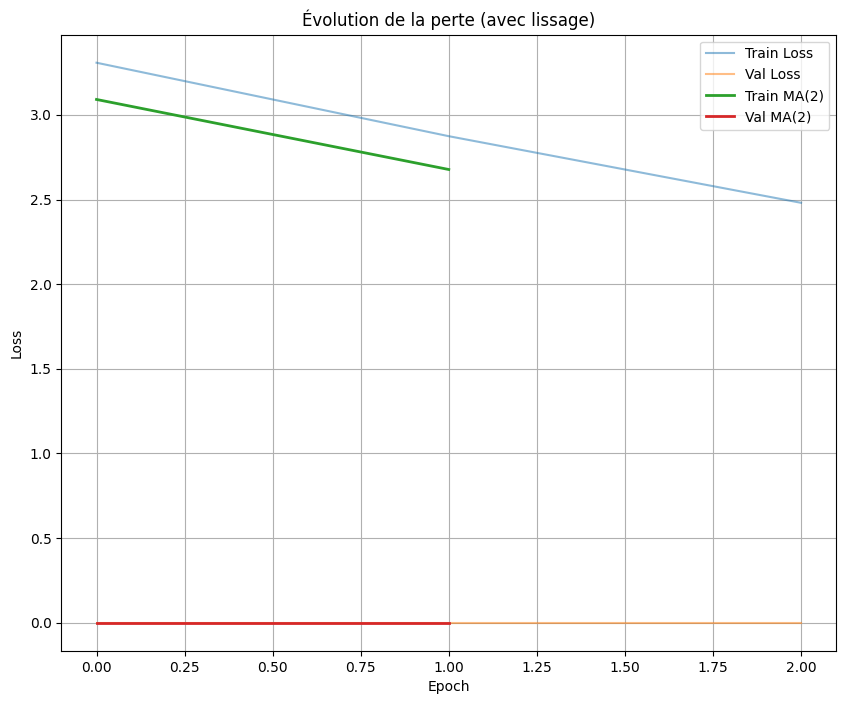

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ----- Fonction moyenne glissante -----
def moving_average(values, window=3):
    return np.convolve(values, np.ones(window)/window, mode='valid')

# ----- Tracé -----
plt.figure(figsize=(10,8))

# Courbes brutes
plt.plot(train_losses, label='Train Loss', alpha=0.5)
plt.plot(val_losses, label='Val Loss', alpha=0.5)

# Courbes lissées (moving average)
plt.plot(moving_average(train_losses, 2), label='Train MA(2)', linewidth=2)
plt.plot(moving_average(val_losses, 2), label='Val MA(2)', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title("Évolution de la perte (avec lissage)")
plt.grid()
plt.show()



## 6. Génération de texte (échantillonnage avec température)

- `temp` ⇢ contrôle la diversité :  
  - **faible** (0.5) → texte plus prévisible,
  - **élevée** (1.0–1.2) → texte plus créatif mais plus instable.


In [ ]:

@torch.no_grad()
def sample_next_token(logits_row, temperature: float = 1.0, top_k: int = None):
    # logits_row: (V,)
    if temperature <= 0:
        temperature = 1e-6
    logits = logits_row / temperature
    if top_k is not None and top_k > 0:
        # ne garder que les top_k meilleurs log-probas
        v, idx = torch.topk(logits, k=min(top_k, logits.numel()))
        mask = torch.full_like(logits, float('-inf'))
        mask[idx] = v
        logits = mask
    probs = torch.softmax(logits, dim=-1)
    idx = torch.multinomial(probs, num_samples=1)
    return idx.item()

@torch.no_grad()
def generate_text(prompt: str, max_new_tokens: int = 400, temperature: float = 0.8, top_k: int = None):
    model.eval()
    # état caché initial (None) ; on traite en streaming pour l'efficacité
    input_ids = torch.tensor([encode(prompt)], dtype=torch.long, device=device)
    hidden = None
    generated = list(prompt)

    # "amorcer" le modèle avec la totalité du prompt
    logits, hidden = model(input_ids, hidden)
    last_token_id = input_ids[0, -1]

    for _ in range(max_new_tokens):
        # on ne passe qu'un seul token à la fois après amorçage
        x = last_token_id.view(1, 1)
        logits, hidden = model(x, hidden)
        next_id = sample_next_token(logits[0, -1], temperature=temperature, top_k=top_k)
        generated.append(itos[next_id])
        last_token_id = torch.tensor(next_id, device=device)

    return ''.join(generated)

# Exemple rapide
print(generate_text("Il était une fois ", max_new_tokens=200, temperature=0.9, top_k=50))


Il était une fois est h janmet le jqe pvnmessatt lrdes pquet lu dsettsg’S use geien dannpasron e ius 
te  e leomane l’onret éanoue le dontkga ea teit nen, ’e qmonton don qulen lonte saoispavooi lupde çuour qanqe àjer i



## 7. Sauvegarde & Rechargement du modèle

Nous enregistrons :
- `model.pth` : poids du réseau,
- `vocab.json` : dictionnaires `stoi/itos` pour générer plus tard sans reconstruire le vocabulaire depuis le corpus.


In [ ]:

SAVE_DIR = 'checkpoints'
os.makedirs(SAVE_DIR, exist_ok=True)

torch.save({
    'model_state_dict': model.state_dict(),
    'config': {
        'vocab_size': vocab_size,
        'emb_dim': 128,
        'hidden_dim': 256,
        'num_layers': 2,
        'dropout': 0.2,
    }
}, os.path.join(SAVE_DIR, 'model.pth'))

with open(os.path.join(SAVE_DIR, 'vocab.json'), 'w', encoding='utf-8') as f:
    json.dump({'stoi': stoi, 'itos': itos}, f, ensure_ascii=False, indent=2)

print('Modèle et vocabulaire sauvegardés dans', SAVE_DIR)


Modèle et vocabulaire sauvegardés dans checkpoints


In [ ]:

# Exemple de rechargement (pour une nouvelle session)
ckpt_path = os.path.join(SAVE_DIR, 'model.pth')
vocab_path = os.path.join(SAVE_DIR, 'vocab.json')

if os.path.isfile(ckpt_path) and os.path.isfile(vocab_path):
    with open(vocab_path, 'r', encoding='utf-8') as f:
        vocab = json.load(f)
    stoi_loaded = {k: int(v) if isinstance(v, str) and v.isdigit() else v for k, v in vocab['stoi'].items()}
    itos_loaded = {int(k): v for k, v in vocab['itos'].items()}
    assert len(itos_loaded) == len(stoi_loaded)

    cfg_ckpt = torch.load(ckpt_path, map_location=device)
    net_cfg = cfg_ckpt['config']
    reloaded = CharLSTM(vocab_size=net_cfg['vocab_size'],
                        emb_dim=net_cfg['emb_dim'],
                        hidden_dim=net_cfg['hidden_dim'],
                        num_layers=net_cfg['num_layers'],
                        dropout=net_cfg['dropout']).to(device)
    reloaded.load_state_dict(cfg_ckpt['model_state_dict'])
    reloaded.eval()
    print('Modèle rechargé. Exemple de génération :')
    # petite génération pour valider
    with torch.no_grad():
        def encode_loaded(s: str):
            return [stoi_loaded[c] for c in s if c in stoi_loaded]
        def generate_with_reloaded(prompt: str, max_new_tokens: int = 200, temperature: float = 0.8, top_k: int = None):
            inp = torch.tensor([encode_loaded(prompt)], dtype=torch.long, device=device)
            hidden = None
            logits, hidden = reloaded(inp, hidden)
            last_id = inp[0, -1]
            out_chars = list(prompt)
            for _ in range(max_new_tokens):
                x = last_id.view(1,1)
                logits, hidden = reloaded(x, hidden)
                nxt = sample_next_token(logits[0,-1], temperature=temperature, top_k=top_k)
                out_chars.append(itos_loaded[nxt])
                last_id = torch.tensor(nxt, device=device)
            return ''.join(out_chars)
        print(generate_with_reloaded('Bonjour ', 200, temperature=0.9, top_k=50))
else:
    print('Aucun checkpoint trouvé à recharger.')


Modèle rechargé. Exemple de génération :
Bonjour p
maiasve cei ut leves sent’trle due denn.ombolt me imient e rus aientonte juet eit dlve que, dairs de le denrre s amuis pace des ejuarailos nles l mo âen ele le le rrdestmmee qu lsoe qoniuoi laie dju


Le TP consiste à entraîner un modèle de langage basé sur des caractères (type GPT ou LSTM) pour prédire le prochain caractère dans un texte, puis générer du texte de manière autonome.